In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from src.getdata_utils import load_data, split_data

In [4]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [6]:
df4=df.copy()
df4.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
import time
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
t0 = time.time()
# ---------------------------
# 1) Use all features except the target
# ---------------------------
assert 'y' in df4.columns, "Expected target column 'y' in df4"
X = df4.drop(columns=['y']).copy()
# Identify numeric vs categorical by dtype (robust)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]
# ---------------------------
# 2) Preprocessing pipelines
# ---------------------------
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
# OneHotEncoder: force DENSE output across sklearn versions
try:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False)
except TypeError:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse=False)
cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', cat_ohe)
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ],
    remainder='drop'
)
# ---------------------------
# 3) KMeans pipeline
# ---------------------------
kmeans_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=4, n_init=10, random_state=42))
])
print("Fitting KMeans pipeline...")
kmeans_pipe.fit(X)
print("Done.")
# Attach clusters back to df4 (doesn't modify X)
df4['cluster'] = kmeans_pipe.named_steps['clusterer'].labels_
# ---------------------------
# 4) Quick sanity checks / summaries
# ---------------------------
print("\nCluster counts:")
print(df4['cluster'].value_counts().sort_index())
if num_features:
    print("\nNumeric means by cluster:")
    print(df4.groupby('cluster')[num_features].mean().round(2))
if cat_features:
    print("\nTop categorical proportions by cluster (all categorical features):")
    for col in cat_features:   # removed [:5]
        ctab = pd.crosstab(df4['cluster'], df4[col], normalize='index').round(3)
        print(f"\n{col} (row = cluster, values = % within cluster)")
        print(ctab)
print(f"\nElapsed: {time.time() - t0:.2f}s")

Fitting KMeans pipeline...
Done.

Cluster counts:
cluster
0    14552
1    21871
2     7002
3     1786
Name: count, dtype: int64

Numeric means by cluster:
           age  balance    day  duration  campaign   pdays  previous
cluster                                                             
0        52.11  2000.29  15.76    245.66      2.43    4.41      0.10
1        33.95   934.38  15.89    275.01      2.26    0.78      0.04
2        39.65  1435.21  14.00    256.56      2.09  247.97      3.42
3        40.43  1117.74  22.29    160.02     14.26   -0.07      0.02

Top categorical proportions by cluster (all categorical features):

job (row = cluster, values = % within cluster)
job      admin.  blue-collar  entrepreneur  housemaid  management  retired  \
cluster                                                                      
0         0.088        0.201         0.040      0.051       0.199    0.137   
1         0.125        0.225         0.029      0.016       0.211    0.002   
2  

In [8]:
cluster_labels = {
    0: "Older, Established Households",
    1: "Young Working Professionals with Debt Exposure",
    2: "Previously Targeted, Mixed Response Clients",
    3: "Over-Contacted, Low Engagement Group"
}
# Replace numbers with labels
df4['cluster_label'] = df4['cluster'].map(cluster_labels)
# Quick check
print(df4[['cluster', 'cluster_label']].head())

   cluster                                   cluster_label
0        0                   Older, Established Households
1        1  Young Working Professionals with Debt Exposure
2        1  Young Working Professionals with Debt Exposure
3        0                   Older, Established Households
4        1  Young Working Professionals with Debt Exposure


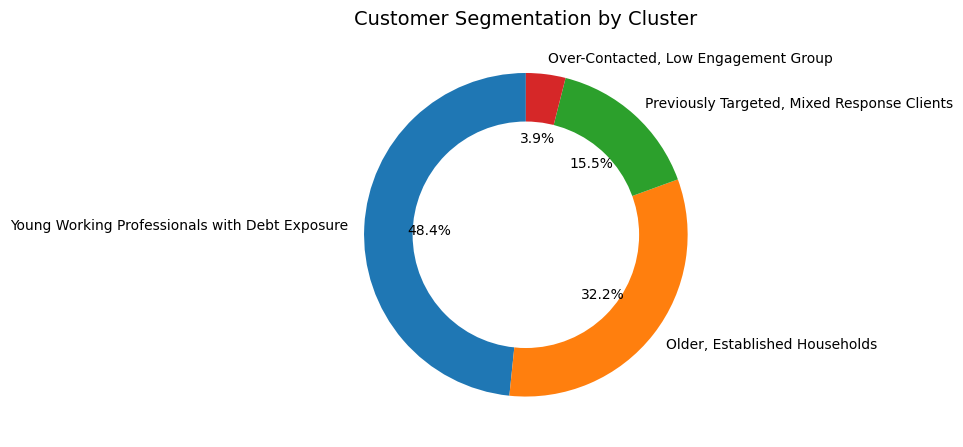

In [9]:
import matplotlib.pyplot as plt
# Get cluster summary percentages
cluster_summary = df4['cluster_label'].value_counts(normalize=True).mul(100).round(2)
# Plot doughnut chart
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    cluster_summary,
    labels=cluster_summary.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # makes it a doughnut
)
# Add a circle in the center for doughnut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
# Title
plt.title("Customer Segmentation by Cluster", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_573758/3974028866.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  in_rate  = tmp[tmp['cluster']==cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
/tmp/ipykernel_573758/3974028866.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out_rate = tmp[tmp['cluster']!=cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
/tmp/ipykernel_573758/3974028866.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']], labels=[S[

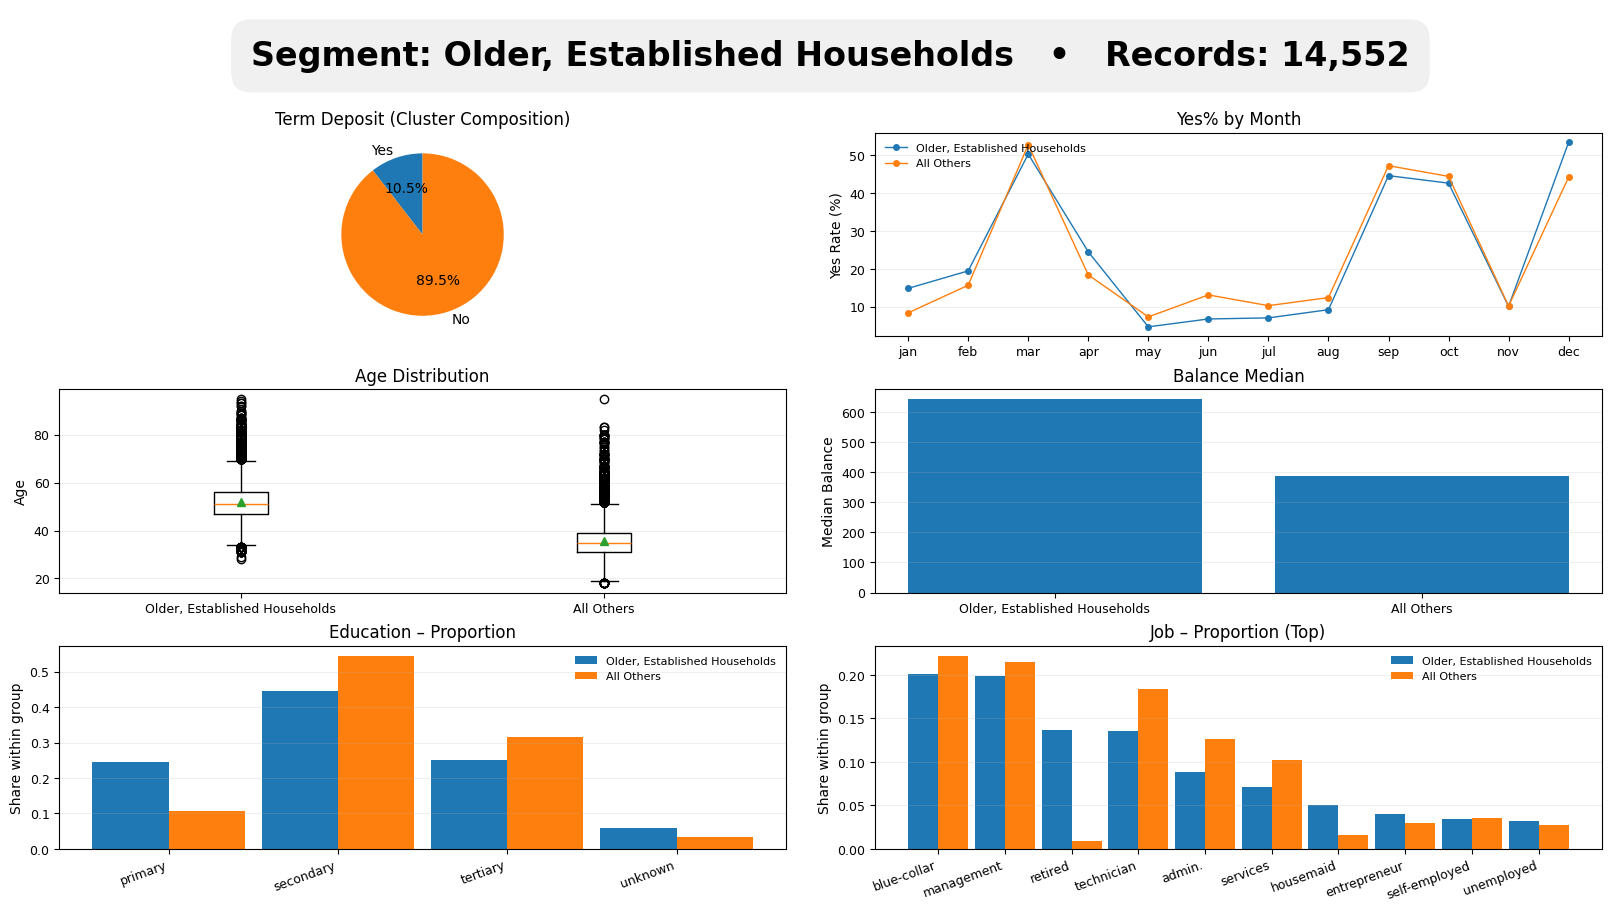

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
def ensure_cluster_label(df4):
    if 'cluster_label' not in df4.columns:
        mapping = {
            0: "Older, Established Households",
            1: "Young Working Professionals with Debt Exposure",
            2: "Previously Targeted, Mixed Response Clients",
            3: "Over-Contacted, Low Engagement Group"
        }
        df4['cluster_label'] = df4['cluster'].map(mapping)
    return df4
def ensure_y_binary(df4):
    if 'y_bin' not in df4.columns:
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4
def _month_cat(series):
    s = series.str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)
def _cluster_id_from_label(df4, label):
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]
def _summaries_for_cluster(df4, cluster_id, job_top_n=10, min_prop=0.01):
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()
    # Age arrays
    age_in, age_out = in_grp['age'].dropna(), out_grp['age'].dropna()
    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()
    # Education proportions (filter small)
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]
    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]
    # Yes/No counts and rates
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)
    yes_out_cnt = int(out_grp['y_bin'].sum())
    no_out_cnt  = int(len(out_grp) - yes_out_cnt)
    # Yes% by month (cluster vs others)
    tmp = df4.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    in_rate  = tmp[tmp['cluster']==cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    out_rate = tmp[tmp['cluster']!=cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    idx = pd.CategoricalIndex(_MONTH_ORDER, ordered=True)
    in_rate, out_rate = in_rate.reindex(idx, fill_value=np.nan), out_rate.reindex(idx, fill_value=np.nan)
    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        yes_pie_in=[yes_in_cnt, no_in_cnt],
        yes_pie_out=[yes_out_cnt, no_out_cnt],
        in_rate=in_rate, out_rate=out_rate
    )
def render_cluster_slide(df4, cluster_label="Older, Established Households", save_path=None):
    df4 = ensure_cluster_label(df4)
    df4 = ensure_y_binary(df4)
    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)
    # 4 rows: Header, KPI row (pie + month), Age/Balance, Education/Job
    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    gs = GridSpec(4, 2, figure=fig, height_ratios=[0.55, 1.2, 1.2, 1.2])
    # ---- Header banner (full width) ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = (df4['cluster_label']==cluster_label).sum()
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.6")
    )
    # ---- Row 2: KPI charts ----
    # Left: PIE (term deposit composition for this cluster)
    ax_pie = fig.add_subplot(gs[1, 0])
    ax_pie.pie(S['yes_pie_in'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_pie.set_title("Term Deposit (Cluster Composition)")
    # Right: Yes% by Month (cluster vs others)
    ax_month = fig.add_subplot(gs[1, 1])
    ax_month.plot(S['in_rate'].index.astype(str), S['in_rate'].values, marker='o', linewidth=1, markersize=4, label=S['label'])
    ax_month.plot(S['out_rate'].index.astype(str), S['out_rate'].values, marker='o', linewidth=1, markersize=4, label="All Others")
    ax_month.set_title("Yes% by Month")
    ax_month.set_ylabel("Yes Rate (%)")
    ax_month.legend(loc='upper left', fontsize=8, frameon=False)
    # ---- Row 3: Age + Balance ----
    ax_age = fig.add_subplot(gs[2, 0])
    ax_age.boxplot([S['age_in'], S['age_out']], labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age")
    ax_bal = fig.add_subplot(gs[2, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    # ---- Row 4: Education + Job ----
    ax_edu = fig.add_subplot(gs[3, 0])
    x = np.arange(len(S['edu_in'])); w = 0.45
    ax_edu.bar(x - w/2, S['edu_in'].values, width=w, label=S['label'])
    ax_edu.bar(x + w/2, S['edu_out'].values, width=w, label="All Others")
    ax_edu.set_xticks(x)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=20, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group")
    ax_edu.legend(loc='upper right', fontsize=8, frameon=False)
    ax_job = fig.add_subplot(gs[3, 1])
    xj = np.arange(len(S['job_in']))
    ax_job.bar(xj - w/2, S['job_in'].values, width=w, label=S['label'])
    ax_job.bar(xj + w/2, S['job_out'].values, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=20, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group")
    ax_job.legend(loc='upper right', fontsize=8, frameon=False)
    # light y-grids + consistent tick font
    for ax in [ax_month, ax_age, ax_bal, ax_edu, ax_job]:
        ax.grid(True, axis='y', linewidth=0.5, alpha=0.3)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
# Run for "Older, Established Households"
render_cluster_slide(df4, cluster_label="Older, Established Households")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
def ensure_cluster_label(df4):
    if 'cluster_label' not in df4.columns:
        mapping = {
            0: "Older, Established Households",
            1: "Young Working Professionals with Debt Exposure",
            2: "Previously Targeted, Mixed Response Clients",
            3: "Over-Contacted, Low Engagement Group"
        }
        df4['cluster_label'] = df4['cluster'].map(mapping)
    return df4
def ensure_y_binary(df4):
    if 'y_bin' not in df4.columns:
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4
def _month_cat(series):
    s = series.str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)
def _cluster_id_from_label(df4, label):
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]
def _summaries_for_cluster(df4, cluster_id, job_top_n=10, min_prop=0.01):
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()
    # Age arrays
    age_in, age_out = in_grp['age'].dropna(), out_grp['age'].dropna()
    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()
    # Education proportions (filter small)
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]
    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]
    # Yes/No counts and rates
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)
    yes_out_cnt = int(out_grp['y_bin'].sum())
    no_out_cnt  = int(len(out_grp) - yes_out_cnt)
    # Yes% by month (cluster vs others)
    tmp = df4.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    in_rate  = tmp[tmp['cluster']==cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    out_rate = tmp[tmp['cluster']!=cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    idx = pd.CategoricalIndex(_MONTH_ORDER, ordered=True)
    in_rate, out_rate = in_rate.reindex(idx, fill_value=np.nan), out_rate.reindex(idx, fill_value=np.nan)
    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        yes_pie_in=[yes_in_cnt, no_in_cnt],
        yes_pie_out=[yes_out_cnt, no_out_cnt],
        in_rate=in_rate, out_rate=out_rate
    )
def render_cluster_slide(df4, cluster_label="Older, Established Households", save_path=None):
    df4 = ensure_cluster_label(df4)
    df4 = ensure_y_binary(df4)
    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)
    # 4 rows: Header, KPI row (pie + month), Age/Balance, Education/Job
    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    gs = GridSpec(4, 2, figure=fig, height_ratios=[0.55, 1.2, 1.2, 1.2])
    # ---- Header banner (full width) ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = (df4['cluster_label']==cluster_label).sum()
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.6")
    )
    # ---- Row 2: KPI charts ----
    # Left: PIE (term deposit composition for this cluster)
    ax_pie = fig.add_subplot(gs[1, 0])
    ax_pie.pie(S['yes_pie_in'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_pie.set_title("Term Deposit (Cluster Composition)")
    # Right: Yes% by Month (cluster vs others)
    ax_month = fig.add_subplot(gs[1, 1])
    ax_month.plot(S['in_rate'].index.astype(str), S['in_rate'].values, marker='o', linewidth=1, markersize=4, label=S['label'])
    ax_month.plot(S['out_rate'].index.astype(str), S['out_rate'].values, marker='o', linewidth=1, markersize=4, label="All Others")
    ax_month.set_title("Yes% by Month")
    ax_month.set_ylabel("Yes Rate (%)")
    ax_month.legend(loc='upper left', fontsize=8, frameon=False)
    # ---- Row 3: Age + Balance ----
    ax_age = fig.add_subplot(gs[2, 0])
    ax_age.boxplot([S['age_in'], S['age_out']], labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age")
    ax_bal = fig.add_subplot(gs[2, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    # ---- Row 4: Education + Job ----
    ax_edu = fig.add_subplot(gs[3, 0])
    x = np.arange(len(S['edu_in'])); w = 0.45
    ax_edu.bar(x - w/2, S['edu_in'].values, width=w, label=S['label'])
    ax_edu.bar(x + w/2, S['edu_out'].values, width=w, label="All Others")
    ax_edu.set_xticks(x)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=20, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group")
    ax_edu.legend(loc='upper right', fontsize=8, frameon=False)
    ax_job = fig.add_subplot(gs[3, 1])
    xj = np.arange(len(S['job_in']))
    ax_job.bar(xj - w/2, S['job_in'].values, width=w, label=S['label'])
    ax_job.bar(xj + w/2, S['job_out'].values, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=20, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group")
    ax_job.legend(loc='upper right', fontsize=8, frameon=False)
    # light y-grids + consistent tick font
    for ax in [ax_month, ax_age, ax_bal, ax_edu, ax_job]:
        ax.grid(True, axis='y', linewidth=0.5, alpha=0.3)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
# Run for "Older, Established Households"
render_cluster_slide(df4, cluster_label="Older, Established Households")

/tmp/ipykernel_573758/703192356.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  in_rate  = tmp[tmp['cluster']==cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
/tmp/ipykernel_573758/703192356.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out_rate = tmp[tmp['cluster']!=cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
/tmp/ipykernel_573758/703192356.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']],


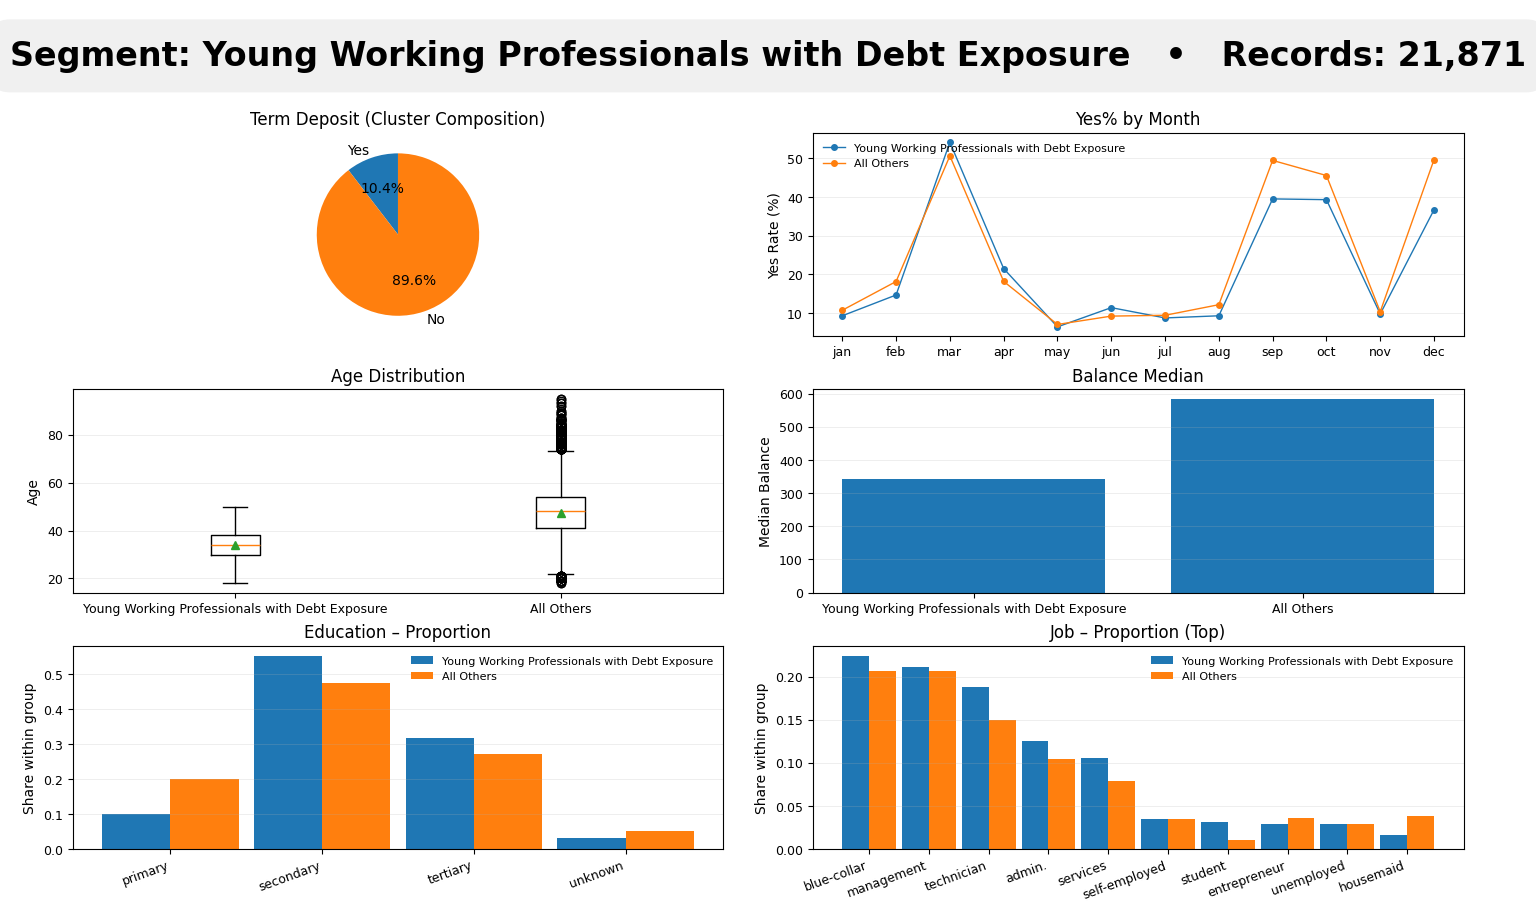

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --------- CONFIG ---------
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
_CLUSTER_LABELS = {
    0: "Older, Established Households",
    1: "Young Working Professionals with Debt Exposure",
    2: "Previously Targeted, Mixed Response Clients",
    3: "Over-Contacted, Low Engagement Group"
}

# --------- HELPERS ---------
def ensure_cluster_label(df4: pd.DataFrame) -> pd.DataFrame:
    """Add a human-readable label for each numeric cluster id."""
    if 'cluster_label' not in df4.columns:
        df4['cluster_label'] = df4['cluster'].map(_CLUSTER_LABELS)
    return df4

def ensure_y_binary(df4: pd.DataFrame) -> pd.DataFrame:
    """Create a binary target (1=yes, 0=no) for term deposit."""
    if 'y_bin' not in df4.columns:
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4

def _month_cat(series: pd.Series) -> pd.Categorical:
    """Order month abbreviations correctly for plotting."""
    s = series.str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)

def _cluster_id_from_label(df4: pd.DataFrame, label: str) -> int:
    """Find numeric cluster id given the label string."""
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]

def _summaries_for_cluster(df4: pd.DataFrame, cluster_id: int,
                           job_top_n: int = 10, min_prop: float = 0.01) -> dict:
    """Compute all summaries needed for the slide."""
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()

    # Age arrays
    age_in  = in_grp['age'].dropna()
    age_out = out_grp['age'].dropna()

    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()

    # Education proportions (filter small)
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]

    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]

    # Term deposit composition (counts) for pie
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)
    yes_out_cnt = int(out_grp['y_bin'].sum())
    no_out_cnt  = int(len(out_grp) - yes_out_cnt)

    # Yes% by month (cluster vs others)
    tmp = df4.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    in_rate  = tmp[tmp['cluster']==cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    out_rate = tmp[tmp['cluster']!=cluster_id].groupby('month_cat')['y_bin'].mean().mul(100)
    idx = pd.CategoricalIndex(_MONTH_ORDER, ordered=True)
    in_rate  = in_rate.reindex(idx, fill_value=np.nan)
    out_rate = out_rate.reindex(idx, fill_value=np.nan)

    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        yes_pie_in=[yes_in_cnt, no_in_cnt],
        yes_pie_out=[yes_out_cnt, no_out_cnt],
        in_rate=in_rate, out_rate=out_rate
    )

# --------- MAIN RENDERER ---------
def render_cluster_slide(df4: pd.DataFrame, cluster_label: str,
                         save_path: str | None = None) -> None:
    """Render a wide slide for the chosen cluster."""
    df4 = ensure_cluster_label(df4)
    df4 = ensure_y_binary(df4)
    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)

    # 4 rows: Header, KPI row (pie + month), Age/Balance, Education/Job
    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    gs = GridSpec(4, 2, figure=fig, height_ratios=[0.55, 1.2, 1.2, 1.2])

    # Header banner (full width)
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = int((df4['cluster_label']==cluster_label).sum())
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.6")
    )

    # Row 2: KPI charts
    # Left: PIE (term deposit composition for this cluster)
    ax_pie = fig.add_subplot(gs[1, 0])
    ax_pie.pie(S['yes_pie_in'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_pie.set_title("Term Deposit (Cluster Composition)")

    # Right: Yes% by Month (cluster vs others)
    ax_month = fig.add_subplot(gs[1, 1])
    ax_month.plot(S['in_rate'].index.astype(str), S['in_rate'].values,
                  marker='o', linewidth=1, markersize=4, label=S['label'])
    ax_month.plot(S['out_rate'].index.astype(str), S['out_rate'].values,
                  marker='o', linewidth=1, markersize=4, label="All Others")
    ax_month.set_title("Yes% by Month")
    ax_month.set_ylabel("Yes Rate (%)")
    ax_month.legend(loc='upper left', fontsize=8, frameon=False)

    # Row 3: Age + Balance
    ax_age = fig.add_subplot(gs[2, 0])
    ax_age.boxplot([S['age_in'], S['age_out']],
                   labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age")

    ax_bal = fig.add_subplot(gs[2, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")

    # Row 4: Education + Job
    ax_edu = fig.add_subplot(gs[3, 0])
    x = np.arange(len(S['edu_in'])); w = 0.45
    ax_edu.bar(x - w/2, S['edu_in'].values, width=w, label=S['label'])
    ax_edu.bar(x + w/2, S['edu_out'].values, width=w, label="All Others")
    ax_edu.set_xticks(x)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=20, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group")
    ax_edu.legend(loc='upper right', fontsize=8, frameon=False)

    ax_job = fig.add_subplot(gs[3, 1])
    xj = np.arange(len(S['job_in']))
    ax_job.bar(xj - w/2, S['job_in'].values, width=w, label=S['label'])
    ax_job.bar(xj + w/2, S['job_out'].values, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=20, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group")
    ax_job.legend(loc='upper right', fontsize=8, frameon=False)

    # Light y-grids + consistent tick font
    for ax in [ax_month, ax_age, ax_bal, ax_edu, ax_job]:
        ax.grid(True, axis='y', linewidth=0.5, alpha=0.3)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

def render_cluster_slide_by_id(df4: pd.DataFrame, cluster_id: int, **kwargs) -> None:
    """Convenience wrapper to render by numeric id."""
    df4 = ensure_cluster_label(df4)
    label = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    render_cluster_slide(df4, cluster_label=label, **kwargs)

# --------- CALL: Cluster 2 ("Young Working Professionals with Debt Exposure") ---------
# Option A (by label):
render_cluster_slide(df4, cluster_label="Young Working Professionals with Debt Exposure")

# Option B (by numeric id = 1):
# render_cluster_slide_by_id(df4, 1, save_path="slide_young_working.png")
